# **Triangle Inequalities of Matrix Absolute Value**: Programming Notes

Christopher Ramsey, Michael Francis, Jordan Kaseram, Osman Jime

MacEwan Univeristy, Edmonton Alberta Canada.

*Last Updated July 4th, 2024*

##### **The Triangle Inequality**

A **norm** is a mathematical function, $|\cdot|: V \rightarrow W$ that defines the distance of some element. A fundamental property of distance is that the path to $A$ and then to $B$ can never be shorter then the path directly to $B$. This property is called the **triangle inequality**, and is formulated as:

$$
|A| + |B| \geq |A+B|
$$

The triangle inequality can be computational verified by asserting that $|A| + |B| - |A+B| \geq 0$. To do this, we need to first define two things:
1. A function, `length(v) -> w`, that maps elements $v\in V$ to distance elements $w\in W$.
2. A function `positive(w) -> bool`, that yeilds `true` if $w$ is positive, and false otherwise.

We define a helper function in our research methods, `triangle_inequality(A,B, length, positive) -> bool` that verifies if the triangle inequality holds for elements $A$ and $B$, using some user defined functions, `length` and `positive`.

##### **The Matrix Absolute Value**

Consider the function, $|\cdot|: M_{n}(\mathbb C) \rightarrow M_{n}(\mathbb C)$, as:

$$
    |A|=(A^*A)^\frac{1}{2}
$$

This is the **absolute value** of matrix A. Just as the square root of a real number, $c^\frac{1}{2}$ is defined as: 

$$
c = c^\frac{1}{2}c^\frac{1}{2}
$$

We define the square root of any matrix, $M$ as:

$$
 M^{\frac{1}{2}} : \{ N \mid N \in M_{n}(\mathbb C), M = N^2 \}  
$$

Finding the square root for any abitrary matrix, $M$, is not always feasible, however, if $M$ is diagonalizable, then there exists a **spectral decomposition** of $M$ in the form:

$$
M = PDP^* =
\begin{bmatrix}
x_1 & x_2 & \cdots & x_n
\end{bmatrix}
\begin{bmatrix}
\lambda_1 \\
& \lambda_2 \\
&& \cdot \\
&&& \cdot \\
&&&& \lambda_n \\
\end{bmatrix}
\begin{bmatrix}
x_1^* \\
x_2^* \\
\cdot \\
\cdot \\
x_n^* 
\end{bmatrix}
$$

where $P$ is an unitary matrix composed of orthonormal eigenvectors $x$ of $M$, and $D$ is a matrix with only the eigenvalues of $M$ along the diagonal. The row and column index of each eigenvector in $P$ matches the row and column index of its corresponding eigenvalue in $D$.

Now you can define, $M^\frac{1}{2}$ to have a similar spectral decomposition, but with elements of the diagonal matrix, $D$, square rooted:

$$
M^\frac{1}{2} = PD^\frac{1}{2}P^* =
\begin{bmatrix}
x_1 & x_2 & \cdots & x_n
\end{bmatrix}
\begin{bmatrix}
\lambda_1^\frac{1}{2} \\
& \lambda_2^\frac{1}{2} \\
&& \cdot \\
&&& \cdot \\
&&&& \lambda_n^\frac{1}{2} \\
\end{bmatrix}
\begin{bmatrix}
x_1^* \\
x_2^* \\
\cdot \\
\cdot \\
x_n^* 
\end{bmatrix}
$$

Then it can be shown that $M = M^\frac{1}{2}M^\frac{1}{2}$:

$$
M^\frac{1}{2}M^\frac{1}{2}= (PD^\frac{1}{2}P^*) (PD^\frac{1}{2}P^*)=(PD^\frac{1}{2}D^\frac{1}{2}P^*)=PDP^*=M
$$

We define a function in our research methods, `absm_spectral(A)` that determines the absolute value of any matrix, $A \in M_n(\mathbb C)$ using the procedure outlined in this section. The python library, SciPy also includes a matrix square root function using the Schur Decomposition Method. We define a `absm_schur(A)` that uses this scipy method to ensure that our results are independent of implementation.

#### **Positive Semidefinite Matricies**

Since the matrix absolute value yeilds a matrix, the definition of positivity is different from numbers. 

A postivie semidefinite matrix, $A$, is defined as satsifying the following:

1. $A=A^*$
2. $x^*Ax \geq 0$ for all $x\neq0$

For the second condition, recall that if the eigenvectors of $A$ form a basis in $\mathbb C_n$, then a vector $x$ is a linear combiantion of those eigenvectors. If every eignevector has a positive eigenvalue, then $x^*Ax$ will always evaluate to a non-negative value. Thus, one way of determining positivity is determining if all **eigenvalues are greater than or equal zero**.

However, calculating eigenvalues are computationally expensive for large matricies and can be subject to percision problems. An eigenvalue of zero will often appear as an exceedingly small non zero value. Using a tolerance to treat all numbers below it as a zero may work for matricies of small dimensions and entry ranges, but for larger dimensions and entry ranges, it is possible that a real non-zero negative eigenvalue may fall below the tolerance, causing a false positive.

There are two other ways to determine positivity:

1. If a the matrix is **2 dimensional**, the a positive trace (which is equal to the sum of eigenvalues), implies that at least one eignevalue is positive, and a positive determinant (which is equal to the product of eigenvalues), implies that both eignvalues are negative or both eigenvalues are positive. And so a **positive trace and a positive determinant** implies all eigenvalues are positive and thus the matrix is positive definite.

2. (NOT WORKING) If a the matrix is **not 2 dimensional**, we can use decompose the matrix using the Cholesky Decomposition of the form $A=L^*L$. This requires solving a system of linear equations, which computers greatly excel at in comparison to finding the roots of n-dimensional polynomials. If the **Cholesky Decomposition succeeds** then the matrix is positive since for any vector $x$, we have $$x^*Ax=x^*(L^*L)x=(x^*L^*)(Lx)=(Lx)^*(Lx)=||(Lx)||^2>0$$


We define a function in our research methods, `is_psd(A)` that determines the positivty of any matrix, $A \in M_n(\mathbb C)$ by checking if it's eigenvalues are either positivie or not significant with respect to our tolerance.

In addition we also define the alterntive functions to check for positivity, `is_psd_trace_det(A)`, which checks positivity for any matrix, $A \in M_2(\mathbb C)$ by checking it's trace and determinant, and `is_psd_cholesky(A)`, which checks positivity for any matrix $A \in M_n(\mathbb C)$ using the Cholesky Decomposition method. 

These alternative methods ensure that our results are independent of our functions implementation.

The global tolerance or our research methods is $1\times10^{-7}$ and can be set through the variable, `rm.tolerance`.

#### **Computing Triangle Inequality Failures (Random Sample Rates)**

In [ ]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-7
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in ["Integer", "Real", "Gaussian Integer", "Complex"]:
    percentages = []
    for e in entry_ranges:
        sample_size = 100_000
        failed = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=2, min=-e, max=e, type=type, count=2)
            if not rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value,
                positive=rm.is_psd_trace_det,
            ):
                failed += 1
        percentages.append(failed / sample_size)
    df[f"{type}"] = percentages
df.to_csv(f"./data/sample_fail_rates_n2_varied_types_ranges_spec_det.csv", index=False)

In [ ]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-7
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in [
    "Integer",
    "Real",
    "Gaussian Integer",
    "Complex",
]:
    percentages = []
    for e in entry_ranges:
        sample_size = 100_000
        failed = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=2, min=-e, max=e, type=type, count=2)
            if not rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value_scipy,
                positive=rm.is_psd_trace_det,
            ):
                failed += 1
        percentages.append(failed / sample_size)
    df[f"{type}"] = percentages
df.to_csv(f"./data/sample_fail_rates_n2_varied_types_ranges_schur_det.csv", index=False)

In [ ]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-7
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in [
    "Integer",
    "Real",
    "Gaussian Integer",
    "Complex",
]:
    percentages = []
    for e in entry_ranges:
        sample_size = 100_000
        failed = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=2, min=-e, max=e, type=type, count=2)
            if not rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value_scipy,
                positive=rm.is_psd,
            ):
                failed += 1
        percentages.append(failed / sample_size)
    df[f"{type}"] = percentages
df.to_csv(f"./data/sample_fail_rates_n2_varied_types_ranges_schur_eig.csv", index=False)

In [ ]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-7
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in ["Integer", "Real", "Gaussian Integer", "Complex"]:
    percentages = []
    for e in entry_ranges:
        sample_size = 100_000
        failed = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=2, min=-e, max=e, type=type, count=2)
            if not rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value,
                positive=rm.is_psd,
            ):
                failed += 1
        percentages.append(failed / sample_size)
    df[f"{type}"] = percentages
df.to_csv(f"./data/sample_fail_rates_n2_varied_types_ranges_spec_eig.csv", index=False)

In [ ]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-7
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in ["Integer", "Real", "Gaussian Integer", "Complex"]:
    percentages = []
    for e in entry_ranges:
        sample_size = 100_000
        failed = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=3, min=-e, max=e, type=type, count=2)
            if not rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value,
                positive=rm.is_psd,
            ):
                failed += 1
        percentages.append(failed / sample_size)
    df[f"{type}"] = percentages
df.to_csv(f"./data/sample_fail_rates_n3_varied_types_ranges_spec_eig.csv", index=False)

In [ ]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-7
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in ["Integer", "Real", "Gaussian Integer", "Complex"]:
    percentages = []
    for e in entry_ranges:
        sample_size = 100_000
        failed = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=4, min=-e, max=e, type=type, count=2)
            if not rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value,
                positive=rm.is_psd,
            ):
                failed += 1
        percentages.append(failed / sample_size)
    df[f"{type}"] = percentages
df.to_csv(f"./data/sample_fail_rates_n4_varied_types_ranges_spec_eig.csv", index=False)

In [ ]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-7
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in ["Integer", "Real", "Gaussian Integer", "Complex"]:
    percentages = []
    for e in entry_ranges:
        sample_size = 100_000
        failed = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=5, min=-e, max=e, type=type, count=2)
            if not rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value,
                positive=rm.is_psd,
            ):
                failed += 1
        percentages.append(failed / sample_size)
    df[f"{type}"] = percentages
df.to_csv(f"./data/sample_fail_rates_n5_varied_types_ranges_spec_eig.csv", index=False)

In [ ]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-5
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in ["Integer", "Real", "Gaussian Integer", "Complex"]:
    percentages = []
    for e in entry_ranges:
        sample_size = 100_000
        failed = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=2, min=-e, max=e, type=type, count=2)
            if not rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value,
                positive=rm.is_psd,
            ):
                failed += 1
        percentages.append(failed / sample_size)
    df[f"{type}"] = percentages
df.to_csv(
    f"./data/sample_fail_rates_n2_t5_varied_types_ranges_spec_eig.csv", index=False
)

In [ ]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-10
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in ["Integer", "Real", "Gaussian Integer", "Complex"]:
    percentages = []
    for e in entry_ranges:
        sample_size = 100_000
        failed = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=2, min=-e, max=e, type=type, count=2)
            if not rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value,
                positive=rm.is_psd,
            ):
                failed += 1
        percentages.append(failed / sample_size)
    df[f"{type}"] = percentages
df.to_csv(
    f"./data/sample_fail_rates_n2_t10_varied_types_ranges_spec_eig.csv", index=False
)

In [ ]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-15
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in ["Integer", "Real", "Gaussian Integer", "Complex"]:
    percentages = []
    for e in entry_ranges:
        sample_size = 100_000
        failed = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=2, min=-e, max=e, type=type, count=2)
            if not rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value,
                positive=rm.is_psd,
            ):
                failed += 1
        percentages.append(failed / sample_size)
    df[f"{type}"] = percentages
df.to_csv(
    f"./data/sample_fail_rates_n2_t15_varied_types_ranges_spec_eig.csv", index=False
)

In [28]:
import methods as rm
import pandas as pd
import numpy as np

rm.tolerance = 1e-7
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in ["Integer", "Gaussian Integer", "Real", "Complex"]:
    percentages = []
    for e in entry_ranges:
        sample_size = 1_000
        success = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=2, min=-e, max=e, type=type, count=2)
            non_diagonal_entries = [A[0, 1], A[1, 0], B[0, 1], B[1, 0]]
            diagonal_pair = all(entry == 0 for entry in non_diagonal_entries)
            triangle_satisfied = rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value,
                positive=rm.is_psd,
            )
            if diagonal_pair:
                if triangle_satisfied:
                    success += 1
                else:
                    raise ValueError("Symmetric Pair found that does not satisfy")
        percentages.append(success / sample_size)
    df[f"{type}"] = percentages
df.to_csv(
    f"./data/symmetric_success_rates_n2_varied_types_ranges_schur_det.csv", index=False
)

In [23]:
import methods as rm
import pandas as pd

rm.tolerance = 1e-7
entry_ranges = [1, 2, 3, 4, 5]
df = pd.DataFrame({"Entry Range": entry_ranges})
for type in ["Integer", "Gaussian Integer", "Real", "Complex"]:
    percentages = []
    for e in entry_ranges:
        sample_size = 1_000
        success = 0
        for sample in range(sample_size):
            A, B = rm.random_matrix(n=2, min=-e, max=e, type=type, count=2)
            mortad_pair = (
                rm.is_commuting(A, B) and rm.is_hermitian(A) and rm.is_hermitian(B)
            )
            triangle_satisfied = rm.triangle_inequality(
                A,
                B,
                length=rm.matrix_absolute_value,
                positive=rm.is_psd,
            )
            if mortad_pair:
                if triangle_satisfied:
                    success += 1
                else:
                    raise ValueError("Mortad Pair found that does not satisfy")
        percentages.append(success / sample_size)
    df[f"{type}"] = percentages
df.to_csv(
    f"./data/mortad_success_rates_n2_varied_types_ranges_schur_det.csv", index=False
)

### Plotting

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_loaded = pd.read_csv("./data/sample_fail_rates_n2_varied_types_ranges_spec_eig.csv")
entry_ranges = df_loaded["Entry Range"].tolist()
for type in df_loaded.columns:
    if type != "Entry Range":
        percentages = df_loaded[type].tolist()
        plt.plot(
            entry_ranges,
            percentages,
            label=f"Entry Type: {type}",
            linestyle="--",
            marker="o",
        )
plt.title(
    f"""Sample Failure Rate of Triangle Inequality for Absolute Value of 
    100,000 Random 2-D matrices of Varying Entry Ranges and Types.
    
    Tolerance: 1e-7""",
    size=10,
)
plt.xlabel("Max/Min Value of Entry Elements")
plt.ylabel("Failure Rate")
plt.legend()
plt.grid(True)
plt.ylim(0.4, 0.66)
plt.savefig("./latex/assets/sample_fail_rates_n2_varied_types_ranges_spec_eig.pdf")

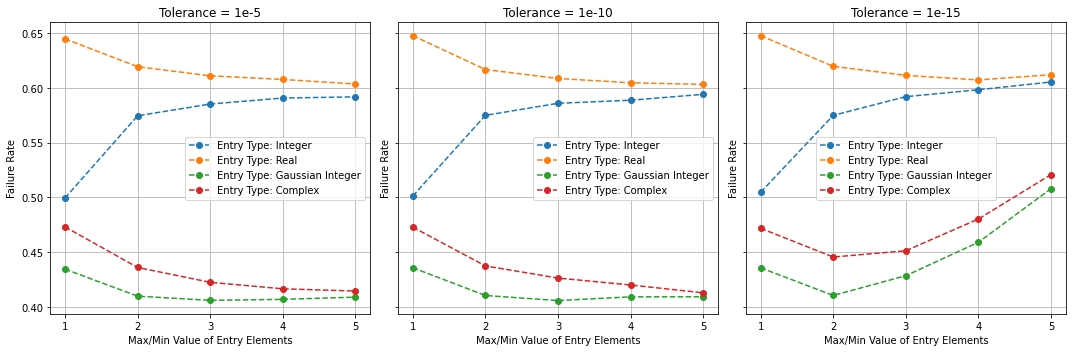

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# File paths for the CSV data
file_paths = [
    "./data/sample_fail_rates_n2_t5_varied_types_ranges_spec_eig.csv",
    "./data/sample_fail_rates_n2_t10_varied_types_ranges_spec_eig.csv",
    "./data/sample_fail_rates_n2_t15_varied_types_ranges_spec_eig.csv",
]

# Create figure and axes for the plots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Column names for the plot lines
plot_columns = ["Integer", "Real", "Gaussian Integer", "Complex"]
subtitles = [
    "Tolerance = 1e-5",
    "Tolerance = 1e-10",
    "Tolerance = 1e-15",
]

# Loop through the file paths and create a plot for each CSV file
for i, (file_path, ax) in enumerate(zip(file_paths, axs)):
    df_loaded = pd.read_csv(file_path)
    entry_ranges = df_loaded["Entry Range"].tolist()
    for type in df_loaded.columns:
        if type != "Entry Range":
            percentages = df_loaded[type].tolist()
            ax.plot(
                entry_ranges,
                percentages,
                label=f"Entry Type: {type}",
                linestyle="--",
                marker="o",
            )
    ax.set_title(subtitles[i])
    ax.set_xlabel("Max/Min Value of Entry Elements")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylabel("Failure Rate")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig("./latex/assets/sample_fail_rates_n2_varied_tolerances_types_range.pdf")

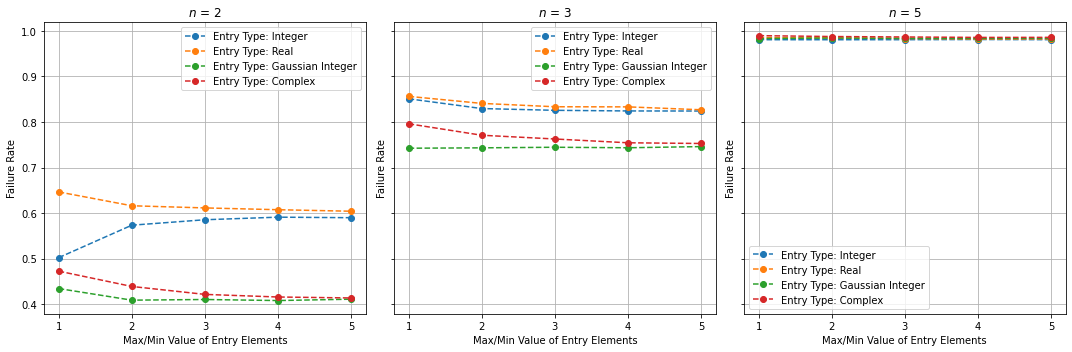

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

file_paths = [
    "./data/sample_fail_rates_n2_varied_types_ranges_spec_eig.csv",
    "./data/sample_fail_rates_n3_varied_types_ranges_spec_eig.csv",
    "./data/sample_fail_rates_n5_varied_types_ranges_spec_eig.csv",
]

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

plot_columns = ["Integer", "Real", "Gaussian Integer", "Complex"]
subtitles = [
    "$n$ = 2",
    "$n$ = 3",
    "$n$ = 5",
]
for i, (file_path, ax) in enumerate(zip(file_paths, axs)):
    df_loaded = pd.read_csv(file_path)
    entry_ranges = df_loaded["Entry Range"].tolist()
    for type in df_loaded.columns:
        if type != "Entry Range":
            percentages = df_loaded[type].tolist()
            ax.plot(
                entry_ranges,
                percentages,
                label=f"Entry Type: {type}",
                linestyle="--",
                marker="o",
            )
    ax.set_title(subtitles[i])
    ax.set_xlabel("Max/Min Value of Entry Elements")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylabel("Failure Rate")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig("./latex/assets/sample_fail_rates_varied_n_types_range.pdf")

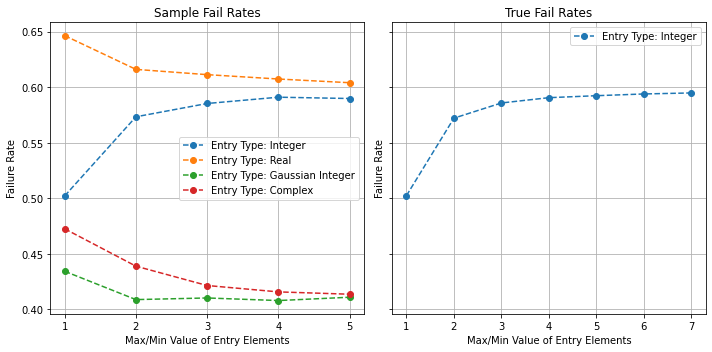

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

file_paths = [
    "./data/sample_fail_rates_n2_varied_types_ranges_spec_eig.csv",
    "./data/true_fail_rates_int_n2_varied_ranges_spec_eig.csv",
]

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

plot_columns = ["Integer"]
subtitles = [
    "Sample Fail Rates",
    "True Fail Rates",
]
for i, (file_path, ax) in enumerate(zip(file_paths, axs)):
    df_loaded = pd.read_csv(file_path)
    entry_ranges = df_loaded["Entry Range"].tolist()
    if i == 0:
        for type in df_loaded.columns[1:]:
            percentages = df_loaded[type].tolist()
            ax.plot(
                entry_ranges,
                percentages,
                label=f"Entry Type: {type}",
                linestyle="--",
                marker="o",
            )
    else:
        percentages = df_loaded["Integer"].tolist()
        ax.plot(
            entry_ranges,
            percentages,
            label=f"Entry Type: Integer",
            linestyle="--",
            marker="o",
        )
    ax.set_title(subtitles[i])
    ax.set_xlabel("Max/Min Value of Entry Elements")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylabel("Failure Rate")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig("./latex/assets/sample_true_fail_rates_n2_varied_types_ranges.pdf")

#### **Computing Triangle Inequality Failures (True Rates)**

In [ ]:
import itertools as it
import methods as rm
import pandas as pd

entry_ranges = [1, 2, 3, 4, 5, 6, 7]
percentages = []
for e in entry_ranges:
    population = 0
    failed = 0
    for A, B in it.product(rm.M_n(-e, e, 2, type="Integer"), repeat=2):
        if not rm.triangle_inequality(
            A,
            B,
            length=rm.matrix_absolute_value,
            positive=rm.is_psd,
        ):
            failed += 1
        population += 1
    percentages.append(failed / population)
df = pd.DataFrame({"Entry Range": entry_ranges, "Integer": percentages})
df.to_csv("./data/true_fail_rates_int_n2_varied_ranges_spec_eig.csv", index=False)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_loaded = pd.read_csv("./data/true_fail_rates_int_n2_varied_ranges_spec_eig.csv")
entry_ranges = df_loaded["Entry Range"].tolist()
percentages = df_loaded["Integer"].tolist()

plt.plot(
    entry_ranges,
    percentages,
    label=f"Entry Type: {type}",
    linestyle="--",
    marker="o",
)
plt.title(
    f"True Failure Rate of Triangle Inequality Failures for\n"
    + r"$M_n(\mathbb{Z}$) with varying entry ranges"
)
plt.xlabel("Max/Min Value of Entry Elements")
plt.ylabel("Failure Rate")
plt.legend()
plt.grid(True)
plt.ylim(0.4, 0.66)
plt.savefig("./latex/assets/true_fail_rates_int_n2_varied_ranges_spec_eig.pdf")